In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

# 2 Hidden layered MLP

### Import Library
- torch
- datasets, transforms
- dataloader

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## Load data for train, test and val split

Tran dataset will be using some augmentations.

In [3]:
transform = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

train_data_set = datasets.ImageFolder("../datasets/final_dataset/train", transform=transform)
val_data_set = datasets.ImageFolder("../datasets/final_dataset/val", transform=transform)

train = DataLoader(
    train_data_set, 
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
    shuffle=True
    )

val = DataLoader(
    val_data_set,
    batch_size=32, 
    num_workers=4, 
    persistent_workers=True, 
    pin_memory=True, 
)

## Train the model

### Load modules and architecture
* Trainer,
* Architecture

In [4]:
from modules.helper.trainer import  Trainer
from modules.architectures.Architecture import Architecture
from modules.helper.charts import gen_line_charts

In [5]:
def find_best_models(df):
    best = df[df["val_accuracy"] == df["val_accuracy"].max()] # combines and remove duplicates
    return best

### Load and Construct a architecture

In [6]:
torch.manual_seed(41)
model = Architecture()

In [7]:
# Input size
flatten_size = 3 * 112 * 112


# Define model
model = nn.Sequential(
    nn.Flatten(),

    # First hidden layer
    nn.Linear(flatten_size, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),

    # Second hidden layer
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    
    # third hidden layer
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    
    # fourth hidden layer
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    # Output layer
    nn.Linear(128, 36)
)

# Calculate trainable parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"TOTAL TRAINABLE PARAMETERS = {total_params:,}")

TOTAL TRAINABLE PARAMETERS = 39,233,700


In [8]:
path = "../documentations/experiments/shreya-mlp-4-layer"

# Using Trainer to train the model
trainer = Trainer(
    model,
    train,
    val,
    optimizer = torch.optim.SGD(
        params=model.parameters(),
        lr=2e-3,
        momentum=0.9,
        weight_decay=3e-5,
    ),
    device="cuda",
    criterion = nn.CrossEntropyLoss()
)

# this is metrics
metrics = trainer.fit(30, path, 1);

EPOCH 5 completed | Training Loss = 0.12194089541668471 | Validation Loss = 0.1464113635176341
EPOCH 10 completed | Training Loss = 0.0484766317346815 | Validation Loss = 0.059768966452346715
EPOCH 15 completed | Training Loss = 0.027314799650145206 | Validation Loss = 0.14475813346513414
EPOCH 20 completed | Training Loss = 0.019049980463564088 | Validation Loss = 0.045468773177996955
EPOCH 25 completed | Training Loss = 0.014047306699050275 | Validation Loss = 0.09492692623031532
EPOCH 30 completed | Training Loss = 0.010284272392140107 | Validation Loss = 0.02413376832303654


## Model with highest Accuracy

In [9]:
find_best_models(metrics)

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
27,28,0.010602,0.025699,0.996952,0.996954,0.996952,0.996952,0.992037,0.992168,0.992037,0.992008


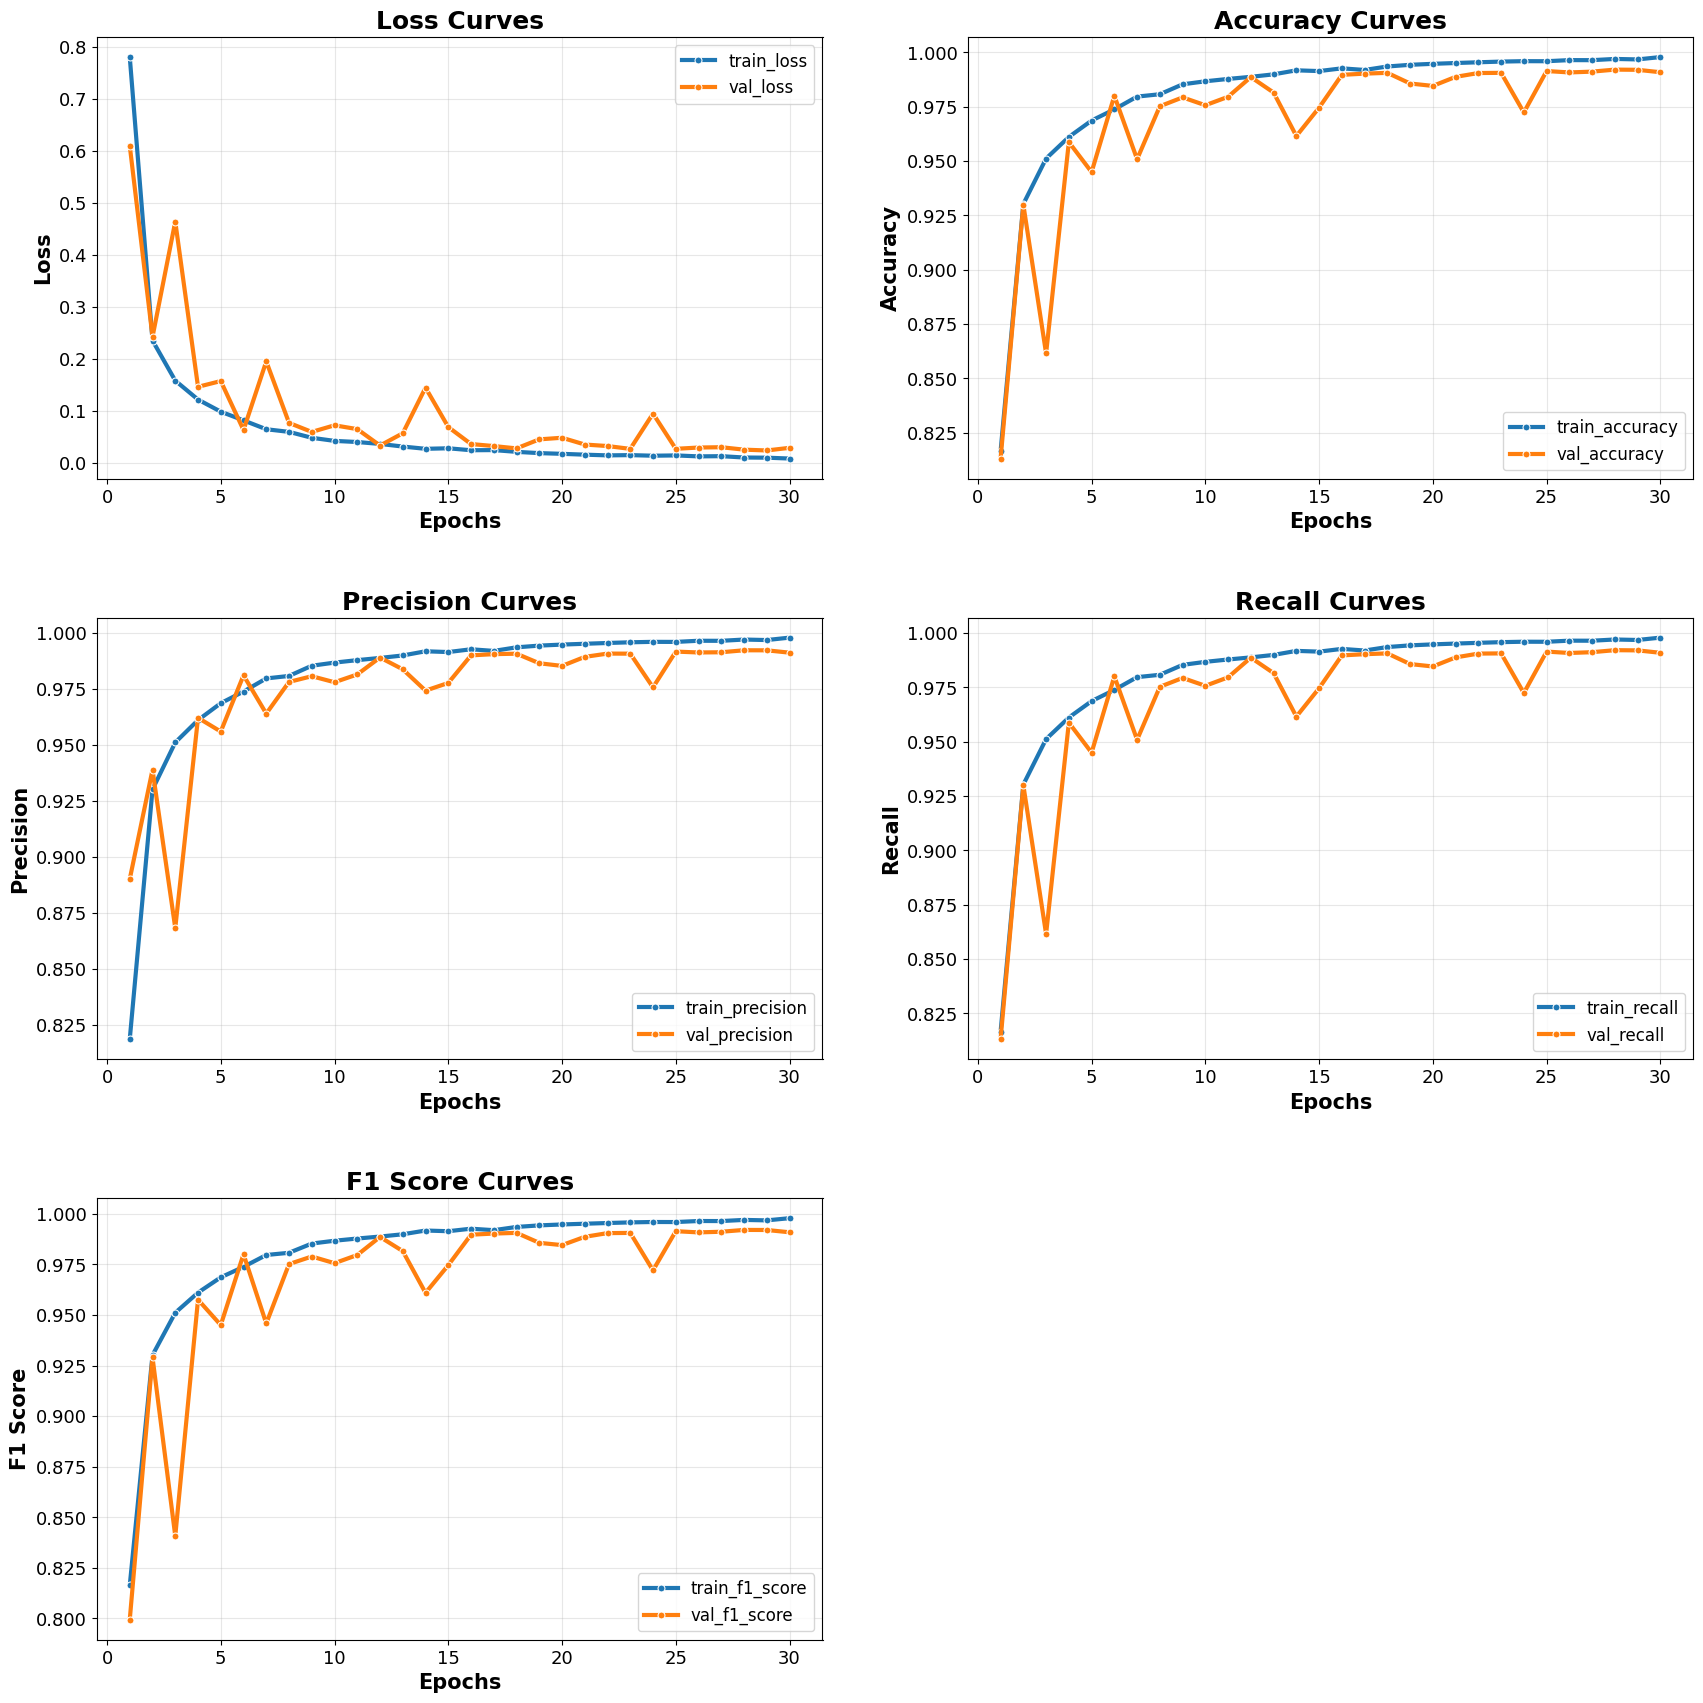

In [10]:
gen_line_charts(metrics, path, "training_metrics_graph.png", ["train_", "val_"])